# LSTM vs GRU vs RNN — AAPL Stock Price Prediction - Tensorflow 

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings

from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')

## 1. Load & Preprocess Data

In [15]:
# General Data

data = pd.read_csv('top50_adjclose_2010_2025.csv')

data.head()

,Date,AAPL,ABBV,ACN,ADBE,AMAT,AMD,AMZN,AVGO,BAC,...,QCOM,RTX,TMO,TSLA,TXN,UNH,V,WFC,WMT,XOM
0,1/4/2010,6.418381,NaN,31.492170,37.090000,11.027142,9.70,6.6950,1.328563,12.169189,...,31.366255,30.905088,44.983402,NaN,17.135918,24.597446,19.645655,18.025999,12.960369,37.881805
1,1/5/2010,6.429481,NaN,31.686804,37.700001,10.942315,9.71,6.7345,1.338425,12.564745,...,32.121357,30.443420,45.134945,NaN,17.037090,24.558432,19.420534,18.520857,12.831314,38.029716
2,1/6/2010,6.327210,NaN,32.023659,37.619999,10.919179,9.57,6.6125,1.348991,12.712109,...,31.807283,30.283791,45.561100,NaN,16.911917,24.800278,19.159752,18.547245,12.802634,38.358402
3,1/7/2010,6.315515,NaN,31.993719,36.889999,10.803512,9.47,6.5000,1.340539,13.130932,...,32.729424,30.413210,45.561100,NaN,16.964617,25.752033,19.338062,19.220257,12.809805,38.237881
4,1/8/2010,6.357502,NaN,31.866446,36.689999,11.219926,9.43,6.6760,1.350401,13.014595,...,33.056866,30.473625,46.328167,NaN,17.353329,25.510187,19.391560,19.042109,12.745278,38.084499


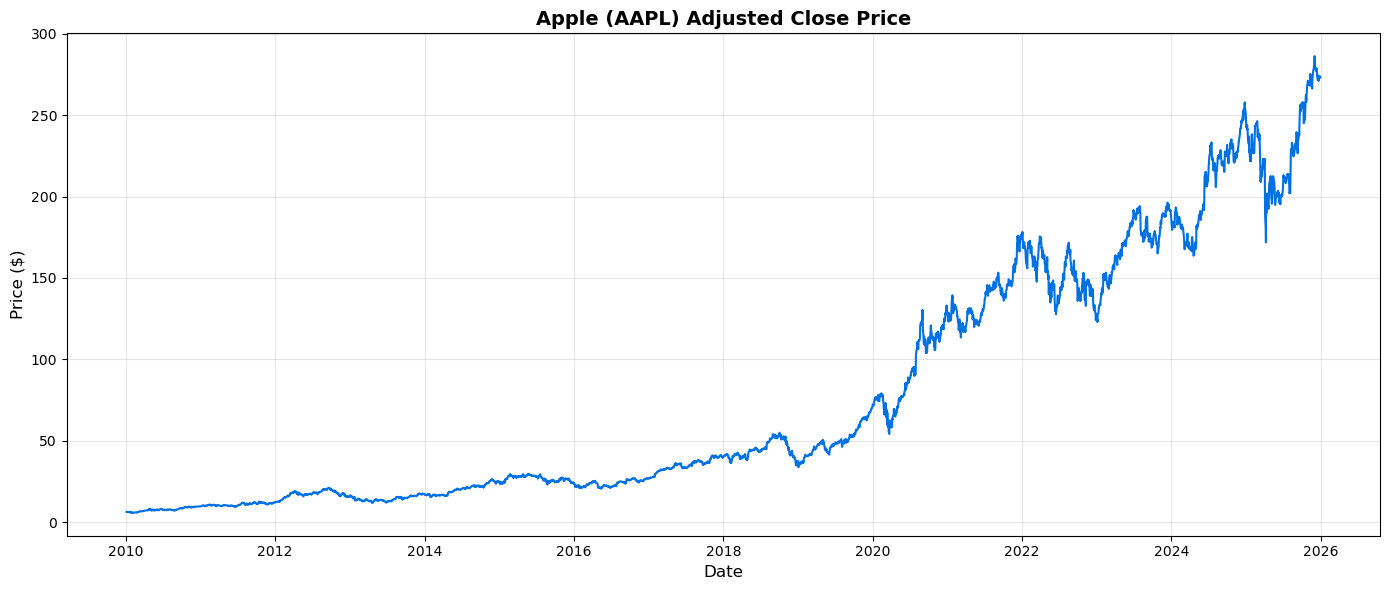

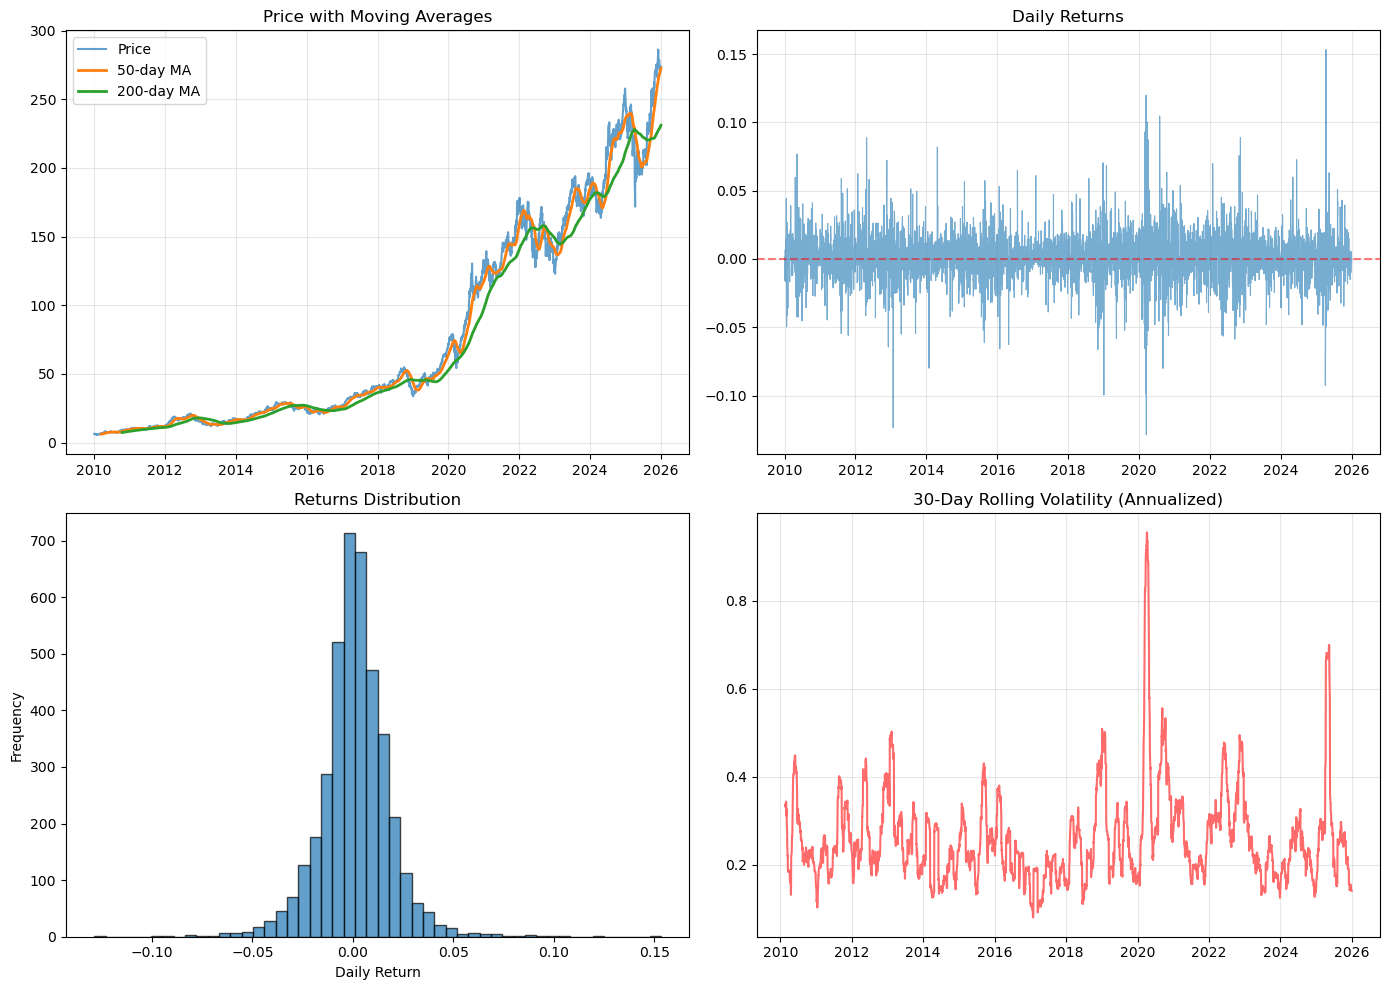

Data range: 2010-01-04 00:00:00 to 2025-12-30 00:00:00
Number of observations: 4023

Price statistics:
count    4023.000000
mean       77.462469
std        74.977193
min         5.759782
25%        18.226905
50%        38.860340
75%       142.910286
max       286.190002
Name: AAPL, dtype: float64


In [16]:
# Extract Apple stock data
apple_data = data[['Date', 'AAPL']].copy()
apple_data['Date'] = pd.to_datetime(apple_data['Date'])
apple_data = apple_data.dropna()

# Basic time series plot
plt.figure(figsize=(14, 6))
plt.plot(apple_data['Date'], apple_data['AAPL'], linewidth=1.5, color='#0071e3')
plt.title('Apple (AAPL) Adjusted Close Price', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Additional exploratory plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price with rolling averages
axes[0, 0].plot(apple_data['Date'], apple_data['AAPL'], label='Price', alpha=0.7)
axes[0, 0].plot(apple_data['Date'], apple_data['AAPL'].rolling(50).mean(), 
                label='50-day MA', linewidth=2)
axes[0, 0].plot(apple_data['Date'], apple_data['AAPL'].rolling(200).mean(), 
                label='200-day MA', linewidth=2)
axes[0, 0].set_title('Price with Moving Averages')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Daily returns
returns = apple_data['AAPL'].pct_change()
axes[0, 1].plot(apple_data['Date'], returns, alpha=0.6, linewidth=0.8)
axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Daily Returns')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of returns
axes[1, 0].hist(returns.dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Returns Distribution')
axes[1, 0].set_xlabel('Daily Return')
axes[1, 0].set_ylabel('Frequency')

# 4. Rolling volatility (30-day)
volatility = returns.rolling(30).std() * np.sqrt(252)  # Annualized
axes[1, 1].plot(apple_data['Date'], volatility, color='#ff6b6b', linewidth=1.5)
axes[1, 1].set_title('30-Day Rolling Volatility (Annualized)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
print(f"Data range: {apple_data['Date'].min()} to {apple_data['Date'].max()}")
print(f"Number of observations: {len(apple_data)}")
print(f"\nPrice statistics:")
print(apple_data['AAPL'].describe())

In [17]:
def create_sequences(data, lookback_window=30):

    X, y = [], []
    for i in range(lookback_window, len(data)):
        X.append(data[i-lookback_window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

In [18]:
# First, create sequences from RAW (unscaled) data
apple_prices = apple_data['AAPL'].values.reshape(-1, 1)

# Create sequences on raw data
lookback = 60
X_raw, y_raw = create_sequences(apple_prices, lookback_window=lookback)

# Split into train/val/test
train_size = int(0.7 * len(X_raw))
val_size = int(0.15 * len(X_raw))

X_train_raw = X_raw[:train_size]
y_train_raw = y_raw[:train_size]

X_val_raw = X_raw[train_size:train_size + val_size]
y_val_raw = y_raw[train_size:train_size + val_size]

X_test_raw = X_raw[train_size + val_size:]
y_test_raw = y_raw[train_size + val_size:]

# Fit scaler ONLY on training data
scaler = MinMaxScaler(feature_range=(0, 1))
X_train = scaler.fit_transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
y_train = scaler.transform(y_train_raw)

# Transform val and test using the SAME scaler
X_val = scaler.transform(X_val_raw.reshape(-1, 1)).reshape(X_val_raw.shape)
y_val = scaler.transform(y_val_raw)

X_test = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)
y_test = scaler.transform(y_test_raw)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Train: 2774 samples
Val:   594 samples
Test:  595 samples


## 2. Model Definitions — RNN & LSTM & GRU

In [19]:
model_rnn = Sequential([
    SimpleRNN(50, activation='tanh', return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    SimpleRNN(50, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

print("Simple RNN Architecture:")
model_rnn.summary()

Simple RNN Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,951 (34.96 KB)

 Trainable params: 8,951 (34.96 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model_lstm = Sequential([
    LSTM(50, activation='tanh', return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(50, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

print("LSTM Architecture:")
model_lstm.summary()

LSTM Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_gru = Sequential([
    GRU(50, activation='tanh', return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    GRU(50, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

## 3. RNN Training Function

In [22]:
history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)],
    verbose=1
)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0200 - mae: 0.0932 - val_loss: 0.0120 - val_mae: 0.0881
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0040 - mae: 0.0409 - val_loss: 0.0090 - val_mae: 0.0809
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0026 - mae: 0.0333 - val_loss: 0.0457 - val_mae: 0.2050
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0020 - mae: 0.0282 - val_loss: 0.0276 - val_mae: 0.1542
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0017 - mae: 0.0254 - val_loss: 0.0207 - val_mae: 0.1342
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013 - mae: 0.0229 - val_loss: 0.0355 - val_mae: 0.1795
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011 - mae: 0.0206 - val_loss: 0.0327 - val_mae: 0.1738
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0011 - mae: 0.0206 - val_loss: 0.0172 - val_mae: 0.1197
Epoch 9/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - lo

## 4. LSTM Training Function

In [23]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)],
    verbose=1
)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0310 - mae: 0.1079 - val_loss: 0.0054 - val_mae: 0.0600
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0016 - mae: 0.0245 - val_loss: 0.0033 - val_mae: 0.0463
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0012 - mae: 0.0197 - val_loss: 0.0157 - val_mae: 0.1129
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0010 - mae: 0.0183 - val_loss: 0.0058 - val_mae: 0.0634
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 9.1574e-04 - mae: 0.0168 - val_loss: 0.0078 - val_mae: 0.0744
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 8.8478e-04 - mae: 0.0167 - val_loss: 0.0047 - val_mae: 0.0557
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 8.1485e-04 - mae: 0.0155 - val_loss: 0.0063 - val_mae: 0.0662
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 8.8217e-04 - mae: 0.0165 - val_loss: 0.0054 - val_mae: 0.0602
Epoch 9/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 3

## 5. GRU Training Function

In [24]:
history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0327 - mae: 0.1058 - val_loss: 9.9635e-04 - val_mae: 0.0251
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0015 - mae: 0.0232 - val_loss: 9.7324e-04 - val_mae: 0.0245
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0011 - mae: 0.0195 - val_loss: 0.0040 - val_mae: 0.0559
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 8.8055e-04 - mae: 0.0180 - val_loss: 0.0021 - val_mae: 0.0389
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 9.2940e-04 - mae: 0.0185 - val_loss: 0.0011 - val_mae: 0.0278
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 7.6111e-04 - mae: 0.0167 - val_loss: 0.0021 - val_mae: 0.0391
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 7.1536e-04 - mae: 0.0151 - val_loss: 0.0023 - val_mae: 0.0409
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 6.1723e-04 - mae: 0.0145 - val_loss: 0.0016 - val_mae: 0.0327
Epoch 9/200
44/44 ━━━━━━━━━━

## 6. Predicted vs Actual — All Models Comparison

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


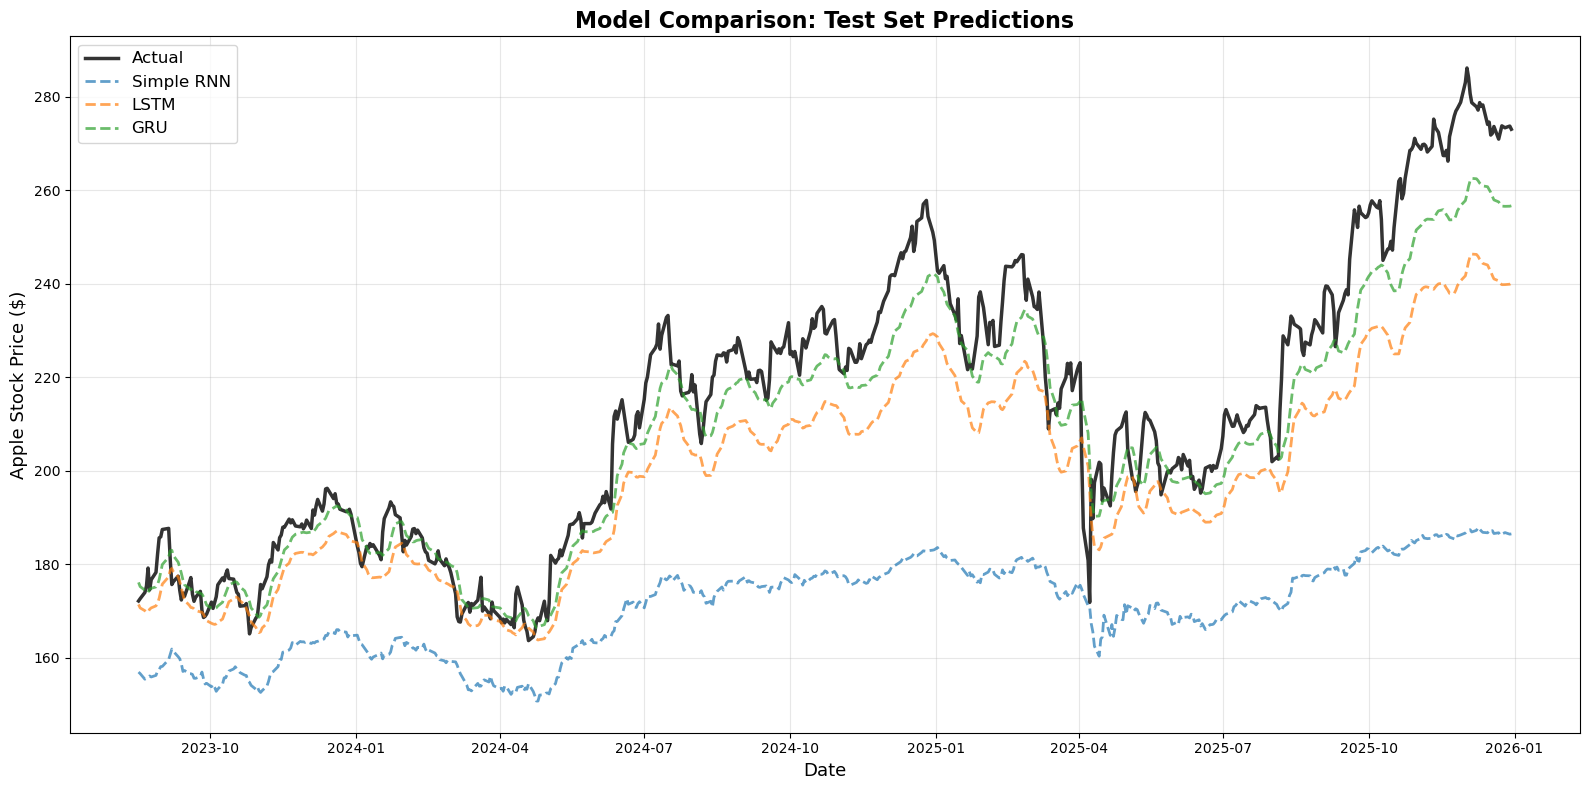

Test Set Performance Metrics:

Simple RNN   - MAE: $42.22  |  RMSE: $47.07  |  MAPE: 18.90%
LSTM         - MAE: $14.07  |  RMSE: $16.95  |  MAPE: 6.19%
GRU          - MAE: $7.24  |  RMSE: $9.33  |  MAPE: 3.21%


In [25]:
# Generate predictions on test set
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)

# Inverse transform to original price scale
y_test_actual = scaler.inverse_transform(y_test)
pred_rnn_actual = scaler.inverse_transform(pred_rnn)
pred_lstm_actual = scaler.inverse_transform(pred_lstm)
pred_gru_actual = scaler.inverse_transform(pred_gru)

# Get corresponding dates for test set
# Test starts at: train_size + val_size + lookback (because of sequence creation)
test_start_idx = train_size + val_size + lookback
test_dates = apple_data['Date'].iloc[test_start_idx:test_start_idx + len(y_test)].values

# Plot comparison
plt.figure(figsize=(16, 8))
plt.plot(test_dates, y_test_actual, label='Actual', linewidth=2.5, color='black', alpha=0.8)
plt.plot(test_dates, pred_rnn_actual, label='Simple RNN', linewidth=2, alpha=0.7, linestyle='--')
plt.plot(test_dates, pred_lstm_actual, label='LSTM', linewidth=2, alpha=0.7, linestyle='--')
plt.plot(test_dates, pred_gru_actual, label='GRU', linewidth=2, alpha=0.7, linestyle='--')

plt.title('Model Comparison: Test Set Predictions', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Apple Stock Price ($)', fontsize=13)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Test Set Performance Metrics:\n")
for name, pred in [('Simple RNN', pred_rnn_actual), 
                    ('LSTM', pred_lstm_actual), 
                    ('GRU', pred_gru_actual)]:
    mae = mean_absolute_error(y_test_actual, pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, pred))
    mape = np.mean(np.abs((y_test_actual - pred) / y_test_actual)) * 100
    
    print(f"{name:12} - MAE: ${mae:.2f}  |  RMSE: ${rmse:.2f}  |  MAPE: {mape:.2f}%")